<h1>ENSO Index - Ensemble Means</h1>

![UFS-logo](../../../UFS-Logo-RGB-2csolidshorizontal-72dpi-min.png)

In [1]:
basedir = f'../../../..'

In [2]:
import os
import sys

# Point to root directory of repository
root_dir = os.path.join(os.getcwd(), basedir)
if root_dir not in sys.path:
    sys.path.insert(0, root_dir)

from src.datareader import datareader as dr
from src.util import util, stats

import warnings
warnings.filterwarnings('ignore')

<h5>Get data readers</h5>

In [3]:
ufs_experiments = ['baseline', 'beta.0.1', 'c96_beta.0.1', 'cpc_ics']

In [4]:
era5_data_reader = dr.getDataReader(datasource='ERA5')

No filename provided; deferring to default
Reading data from gs://gcp-public-data-arco-era5/ar/1959-2022-6h-512x256_equiangular_conservative.zarr


In [5]:
ufs_vars_list = ['tmpsfc', 'tsfc']
era5_var = 'sea_surface_temperature'

In [6]:
era5_data_reader.describe(era5_var)


Variable: sea_surface_temperature
Dimensions: ('time', 'lat', 'lon')
Shape: (92044, 256, 512)
Attributes:
  - long_name: Sea surface temperature
  - short_name: sst
  - units: K


<h5>Define time period</h5>

In [7]:
time_range = ("1994-01-01", "2021-12-31T23")
initmonths = (11,)

<h5>Define nino 3.4 region</h5>

In [8]:
region = {
    'latmin': -5.0,
    'latmax': 5.0,
    'lonmin': 190.0,
    'lonmax':240.0
}

<h5>Get the monthly climatology for nino 3.4</h5>

In [9]:
%%capture captured_output
ufs_ds = util.combine_ufs_means(ufs_experiments, ufs_vars_list, time_range, region=region, initmonths=initmonths)

<h5>Get the corresponding ERA5 data</h5>

In [10]:
era5_ds = era5_data_reader.retrieve(var=era5_var,
                lat=(region['latmin'], region['latmax']),
                lon=(region['lonmin'], region['lonmax']),
                time=time_range)

<h5>Calculate climatology (this may take a couple minutes)</h5>

In [11]:
ufs_stats = stats.calc_climatology_anomaly(ufs_ds, area_mean=True, use_member_climatology=True)

In [12]:
era5_stats = stats.calc_climatology_anomaly(era5_ds, area_mean=True, use_member_climatology=True)

<h5>The calc_climatology_anomaly() function returns a dictionary of statistical datasets.<br>
The keys are:<br>
monthly_mean<br>
monthly_std<br>
climatology_mean<br>
climatology_std<br>
anomaly</h5>

<h2>Plot SST Index and Anomaly</h2>

Generating 4 panel(s).
Processing years 1994 to 1999
Processing years 2000 to 2009
Processing years 2010 to 2019
Processing years 2020 to 2021


<module 'matplotlib.pyplot' from '/home/thamzey/miniforge2/envs/ufs_py311/lib/python3.11/site-packages/matplotlib/pyplot.py'>

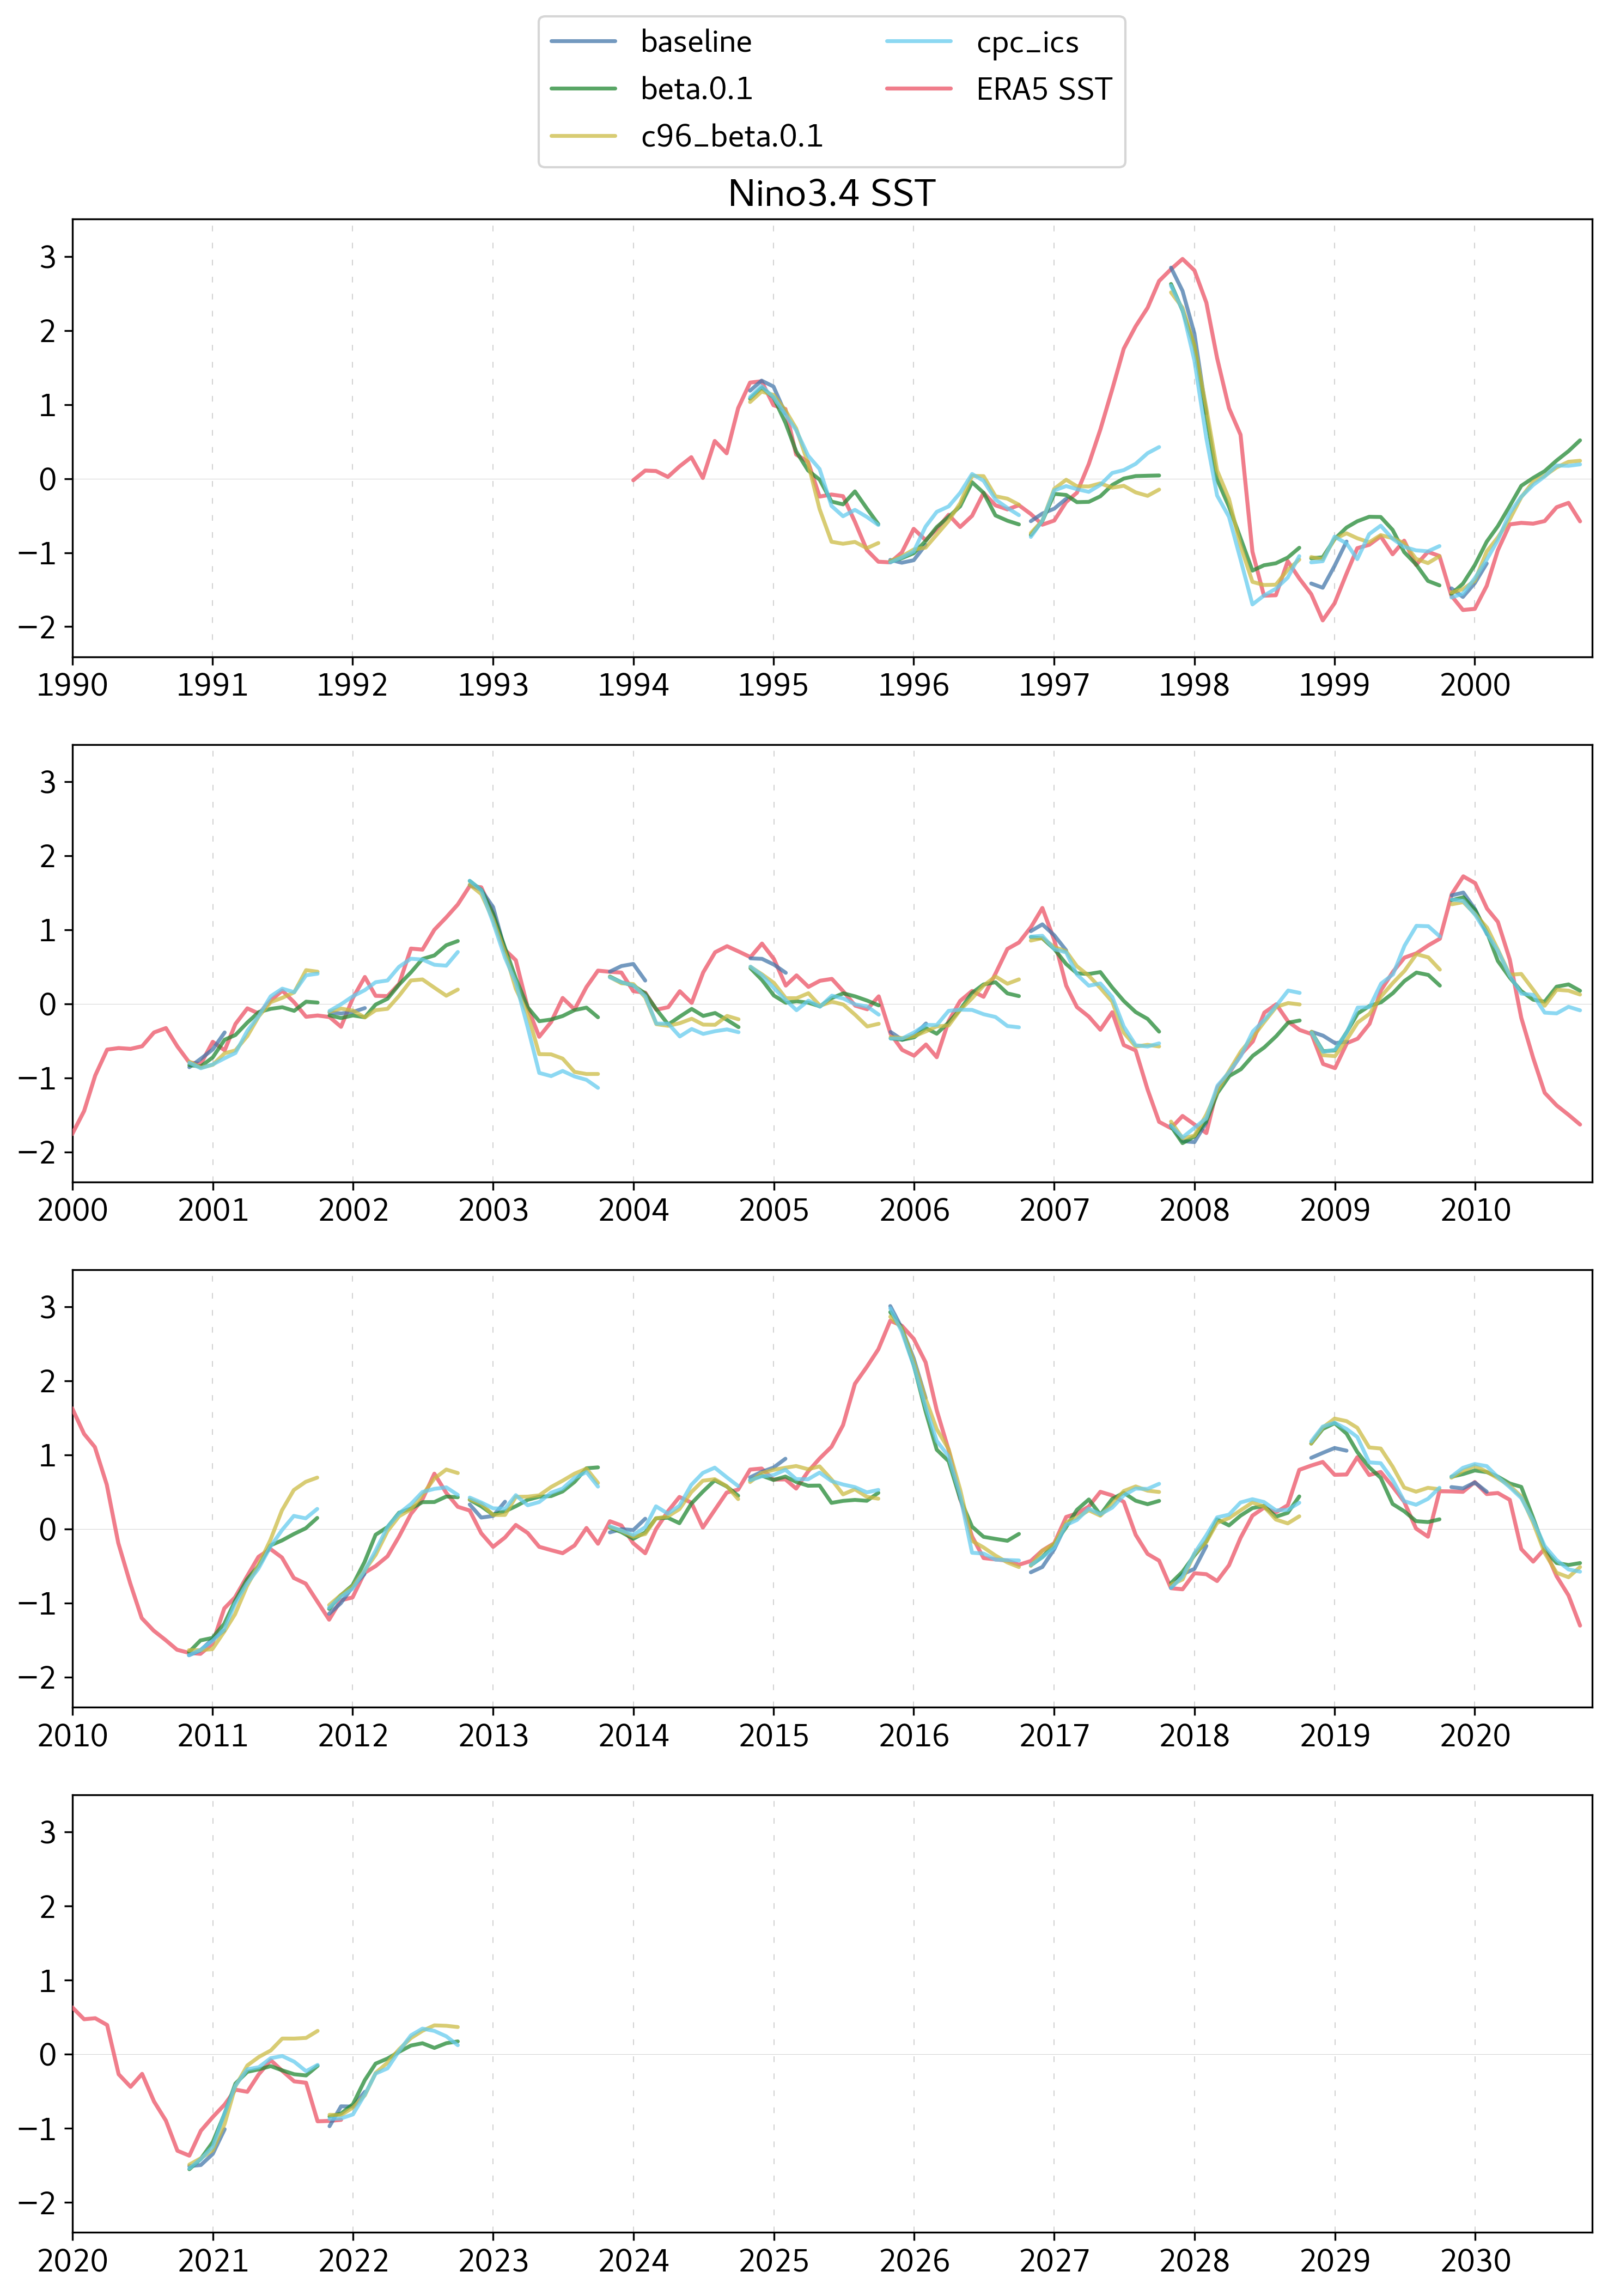

In [13]:
stats.plot_index_spaghetti(ufs_stats=ufs_stats,
                           verif_stats=era5_stats,
                           calc_anomaly=True,
                           title=f'Nino3.4 SST',
                           verif_label='ERA5 SST',
                           dpi=300)